# Breast Cancer Prediction Project

## Objective
The goal of this project is to build a machine learning model that can predict whether a tumor is malignant or benign based on diagnostic measurements.

This can help support early detection of breast cancer and assist medical professionals in decision-making.


In [4]:
!pip install kagglehub

In [47]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [11]:
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
print("Dataset path:", path)

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Dataset path: /kaggle/input/breast-cancer-wisconsin-data


In [12]:
df = pd.read_csv(path + "/data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [14]:
df.shape
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [15]:
print(df['diagnosis'].value_counts())

diagnosis
B    357
M    212
Name: count, dtype: int64


In [16]:
df = df.drop(columns=['id'])

if 'Unnamed: 32' in df.columns:
    df = df.drop(columns=['Unnamed: 32'])

print(df.shape)

(569, 31)


/tmp/ipykernel_1829/2587977883.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette={'M': 'maroon', 'B': 'green'})


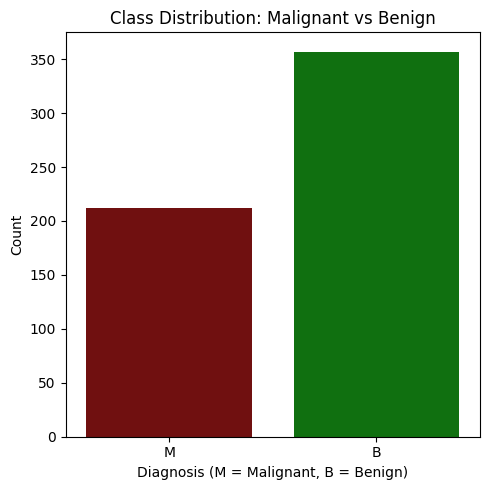

In [26]:
plt.figure(figsize=(5, 5))
sns.countplot(x='diagnosis', data=df, palette={'M': 'maroon', 'B': 'green'})
plt.title('Class Distribution: Malignant vs Benign')
plt.xlabel('Diagnosis (M = Malignant, B = Benign)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [38]:
print(df.groupby('diagnosis')[['radius_mean',
                               'texture_mean',
                               'perimeter_mean',
                               'area_mean',
                               'smoothness_mean',
                               'compactness_mean',
                               'concavity_mean',
                               'symmetry_mean',
                               'concave points_mean',
                               'fractal_dimension_mean']].mean())

           radius_mean  texture_mean  perimeter_mean   area_mean  \
diagnosis                                                          
B            12.146524     17.914762       78.075406  462.790196   
M            17.462830     21.604906      115.365377  978.376415   

           smoothness_mean  compactness_mean  concavity_mean  symmetry_mean  \
diagnosis                                                                     
B                 0.092478          0.080085        0.046058       0.174186   
M                 0.102898          0.145188        0.160775       0.192909   

           concave points_mean  fractal_dimension_mean  
diagnosis                                               
B                     0.025717                0.062867  
M                     0.087990                0.062680  


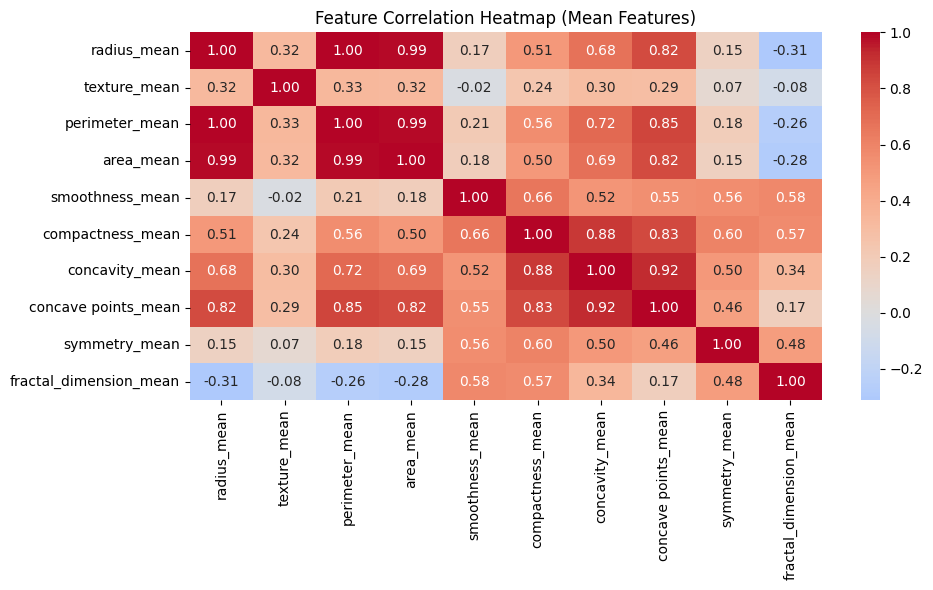

In [37]:
mean_cols = [c for c in df.columns if '_mean' in c]

plt.figure(figsize=(10, 6))
sns.heatmap(df[mean_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap (Mean Features)')
plt.tight_layout()
plt.show()

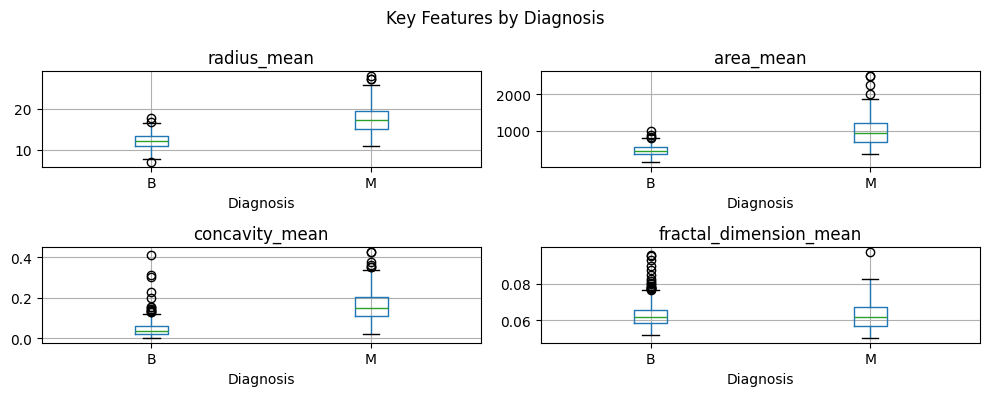

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(10, 4))

features_to_plot = ['radius_mean', 'area_mean',
                    'concavity_mean', 'fractal_dimension_mean']

for ax, feature in zip(axes.flatten(), features_to_plot):
    df.boxplot(column=feature, by='diagnosis', ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('Diagnosis')

plt.suptitle('Key Features by Diagnosis')
plt.tight_layout()
plt.show()

Exploratory data analysis revealed that size-based features (radius, area, perimeter) and shape irregularity (concavity) show the strongest differences between malignant and benign tumours, making them likely important predictors. In contrast, fractal dimension showed almost identical values across both classes, suggesting it contributes little to classification. Notably, radius, perimeter and area are highly correlated with each other, meaning they carry largely redundant information.

In [41]:
# Step 1 — Encode diagnosis column (B=0, M=1)
le = LabelEncoder()
df['diagnosis_encoded'] = le.fit_transform(df['diagnosis'])

print(le.classes_)
print(df[['diagnosis', 'diagnosis_encoded']].head(10))

['B' 'M']
  diagnosis  diagnosis_encoded
0         M                  1
1         M                  1
2         M                  1
3         M                  1
4         M                  1
5         M                  1
6         M                  1
7         M                  1
8         M                  1
9         M                  1


In [42]:
# Step 2 — Split features and target
X = df.drop(columns=['diagnosis', 'diagnosis_encoded'])
y = df['diagnosis_encoded']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (569, 30)
Target shape: (569,)


In [43]:
# Step 3 — Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 455 samples
Test set: 114 samples


In [44]:
# Step 4 — Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before scaling - area_mean range:")
print(f"Min: {X_train['area_mean'].min():.2f}, Max: {X_train['area_mean'].max():.2f}")

print("\nAfter scaling - area_mean range:")
print(f"Min: {X_train_scaled[:, 3].min():.2f}, Max: {X_train_scaled[:, 3].max():.2f}")

Before scaling - area_mean range:
Min: 143.50, Max: 2501.00

After scaling - area_mean range:
Min: -1.43, Max: 5.11


In [46]:
# Train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = rf_model.predict(X_test_scaled)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy:.4f}")

Random Forest Accuracy: 0.9737


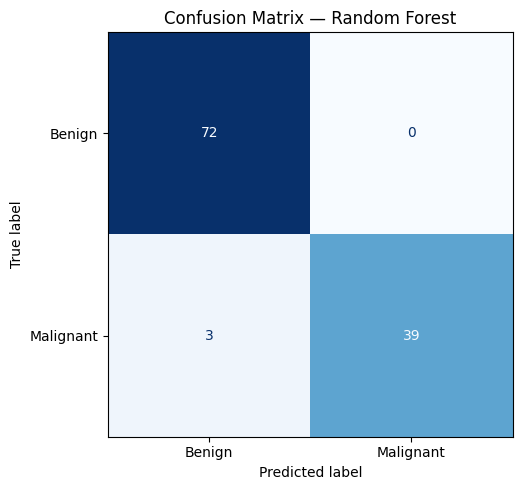

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [48]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Benign', 'Malignant'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()

# Detailed report
print(classification_report(y_test, y_pred,
                            target_names=['Benign', 'Malignant']))

In [49]:
# class weight balanced
rf_balanced = RandomForestClassifier(n_estimators=100,
                                     class_weight='balanced',
                                     random_state=42)
rf_balanced.fit(X_train_scaled, y_train)
y_pred_balanced = rf_balanced.predict(X_test_scaled)

print(classification_report(y_test, y_pred_balanced,
                            target_names=['Benign', 'Malignant']))

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import recall_score

# Define all models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred_model = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_model)
    recall = recall_score(y_test, y_pred_model)
    results[name] = {'accuracy': acc, 'recall': recall}
    print(f"{name}:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Recall:   {recall:.4f}")
    print()

Logistic Regression:
  Accuracy: 0.9649
  Recall:   0.9286

Random Forest:
  Accuracy: 0.9737
  Recall:   0.9286

SVM:
  Accuracy: 0.9737
  Recall:   0.9286

KNN:
  Accuracy: 0.9561
  Recall:   0.9048

Gradient Boosting:
  Accuracy: 0.9649
  Recall:   0.9048



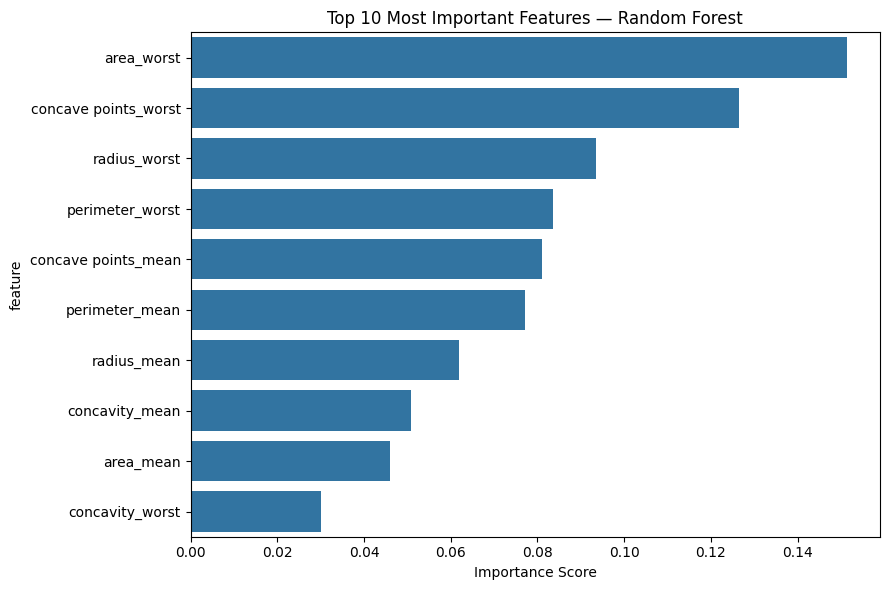

                 feature  importance
23            area_worst    0.151412
27  concave points_worst    0.126497
20          radius_worst    0.093475
22       perimeter_worst    0.083642
7    concave points_mean    0.081082
2         perimeter_mean    0.077126
0            radius_mean    0.061990
6         concavity_mean    0.050818
3              area_mean    0.045916
26       concavity_worst    0.030022


In [52]:
# Feature importance
importances = rf_model.feature_importances_
feature_names = X.columns
feat_df = pd.DataFrame({'feature': feature_names,
                        'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(9, 6))
sns.barplot(x='importance', y='feature', data=feat_df)
plt.title('Top 10 Most Important Features — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(feat_df)

In [53]:
# Get probability scores instead of just 0 or 1
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

# Try different thresholds
thresholds = [0.5, 0.4, 0.3, 0.2]

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    print(f"Threshold {threshold}:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Recall:   {recall:.4f}")
    print()

Threshold 0.5:
  Accuracy: 0.9737
  Recall:   0.9286

Threshold 0.4:
  Accuracy: 0.9649
  Recall:   0.9286

Threshold 0.3:
  Accuracy: 0.9474
  Recall:   0.9286

Threshold 0.2:
  Accuracy: 0.9298
  Recall:   0.9524



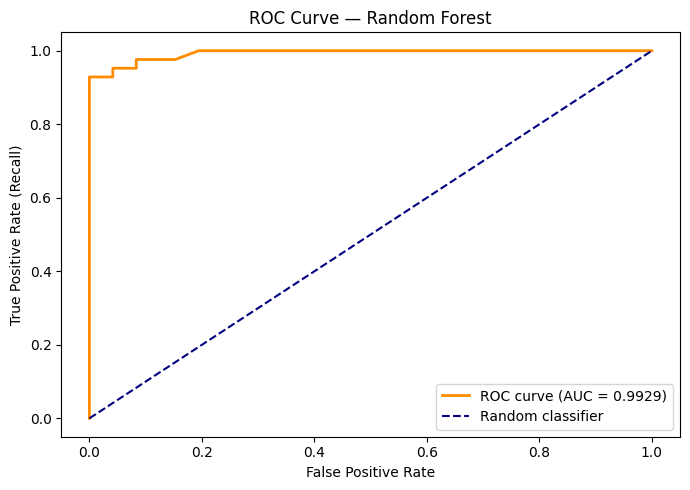

AUC Score: 0.9929


In [54]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5,
         linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Random Forest')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"AUC Score: {roc_auc:.4f}")